In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



df = pd.read_csv("mec_training_dataset_v2.csv")

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df["Vehicle_ID"]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()



Stage1

In [4]:

stage1_num = ["Speed_kmh", "Traffic_Density", "Urgency_Level", "Latitude", "Longitude"]
stage1_cat = ["Road_Type", "Weather", "Data_Type", "MEC_Server_ID"]

stage1_pre = ColumnTransformer([
    ("num", StandardScaler(), stage1_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), stage1_cat),
])

X1_train = stage1_pre.fit_transform(train_df[stage1_num + stage1_cat])
X1_test = stage1_pre.transform(test_df[stage1_num + stage1_cat])
y1_train = train_df["Server_Load_Percent"].values
y1_test = test_df["Server_Load_Percent"].values



n_features_1 = X1_train.shape[1]
X1_train_cnn = X1_train.reshape(-1, n_features_1, 1)
X1_test_cnn = X1_test.reshape(-1, n_features_1, 1)

cnn_stage1 = keras.Sequential([
    layers.Input(shape=(n_features_1, 1)),
    layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1),
])
cnn_stage1.compile(optimizer="adam", loss="mse", metrics=["mae"])
history_cnn1 = cnn_stage1.fit(X1_train_cnn, y1_train, validation_split=0.15, epochs=100,
                               batch_size=64, verbose=1)

pred_load_train = cnn_stage1.predict(X1_train_cnn, verbose=0).flatten()
pred_load_test = cnn_stage1.predict(X1_test_cnn, verbose=0).flatten()

print("--- CNN Stage 1: Server_Load_Percent ---")
print(f"Test R2:  {r2_score(y1_test, pred_load_test):.4f}")
print(f"Test MAE: {mean_absolute_error(y1_test, pred_load_test):.2f} points")



Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5318.5757 - mae: 66.0491 - val_loss: 740.4193 - val_mae: 20.9310
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 884.5927 - mae: 23.1729 - val_loss: 728.8123 - val_mae: 22.9375
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 868.4222 - mae: 23.3193 - val_loss: 706.1637 - val_mae: 21.9823
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 845.1471 - mae: 22.8107 - val_loss: 693.6227 - val_mae: 21.8827
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 836.0525 - mae: 22.7873 - val_loss: 682.4171 - val_mae: 21.7237
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 804.2438 - mae: 22.1166 - val_loss: 674.5328 - val_mae: 21.8382
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 804.3605 - mae: 22.2694 - val_loss: 660.3530 - val_mae: 21.1898
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 784.0573 - mae: 21.9999 - val_loss: 650.0215 - val_mae: 20.6992

evaluate stage 1


In [5]:
print("Stage 1 (Server Load)")
print(f"R² Score : {r2_score(y1_test, pred_load_test):.4f}")
print(f"MAE      : {mean_absolute_error(y1_test, pred_load_test):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y1_test, pred_load_test)):.2f}")


Stage 1 (Server Load)
R² Score : 0.8607
MAE      : 8.46
RMSE     : 10.67


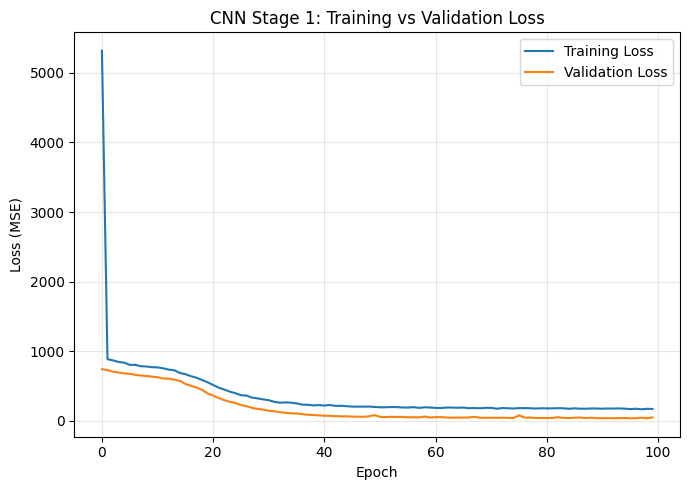

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history_cnn1.history['loss'], label='Training Loss')
plt.plot(history_cnn1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('CNN Stage 1: Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_stage1_loss_curve.png', dpi=300)
plt.show()

Stage 2:Predict Network Latency

In [7]:
# ---------------- STAGE 2: 1D-CNN -> Latency_ms ----------------
stage2_num = [
    "Pred_Load",
    "Speed_kmh",
    "Traffic_Density",
    "Latitude",
    "Longitude",
    "Urgency_Level"
]

stage2_cat = [
    "Road_Type",
    "Weather",
    "Data_Type",
    "MEC_Server_ID"
]

stage2_pre = ColumnTransformer([
    ("num", StandardScaler(), stage2_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), stage2_cat),
])


train_df["Pred_Load"] = pred_load_train
test_df["Pred_Load"] = pred_load_test



X2_train = stage2_pre.fit_transform(train_df[stage2_num + stage2_cat])
X2_test = stage2_pre.transform(test_df[stage2_num + stage2_cat])
y2_train = train_df["Latency_ms"].values
y2_test = test_df["Latency_ms"].values

n_features_2 = X2_train.shape[1]
X2_train_cnn = X2_train.reshape(-1, n_features_2, 1)
X2_test_cnn = X2_test.reshape(-1, n_features_2, 1)

cnn_stage2 = keras.Sequential([
    layers.Input(shape=(n_features_2, 1)),
    layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1),
])
cnn_stage2.compile(optimizer="adam", loss="mse", metrics=["mae"])
history_cnn2 = cnn_stage2.fit(X2_train_cnn, y2_train, validation_split=0.15, epochs=100,
                               batch_size=64, verbose=1)

pred_latency_test = cnn_stage2.predict(X2_test_cnn, verbose=0).flatten()




Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 387.2287 - mae: 16.5942 - val_loss: 42.8365 - val_mae: 5.2443
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 53.5154 - mae: 5.8215 - val_loss: 38.7324 - val_mae: 5.0062
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 51.5991 - mae: 5.7150 - val_loss: 37.9635 - val_mae: 4.9521
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 50.9897 - mae: 5.6548 - val_loss: 37.8607 - val_mae: 4.9423
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 49.9043 - mae: 5.6053 - val_loss: 37.2858 - val_mae: 4.8959
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 50.5839 - mae: 5.6621 - val_loss: 37.7377 - val_mae: 4.9294
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 49.7385 - mae: 5.5991 - val_loss: 37.1917 - val_mae: 4.8924
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 48.4301 - mae: 5.5478 - val_loss: 36.9091 - val_mae: 4.8678
Epoch 9/100
105/105 ━━━━━━━━

evaluting stage 2 performance

In [8]:
print("\nStage 2 (Latency)")
print(f"R² Score : {r2_score(y2_test, pred_latency_test):.4f}")
print(f"MAE      : {mean_absolute_error(y2_test, pred_latency_test):.2f} ms")
print(f"RMSE     : {np.sqrt(mean_squared_error(y2_test, pred_latency_test)):.2f} ms")


Stage 2 (Latency)
R² Score : 0.0158
MAE      : 5.77 ms
RMSE     : 7.21 ms


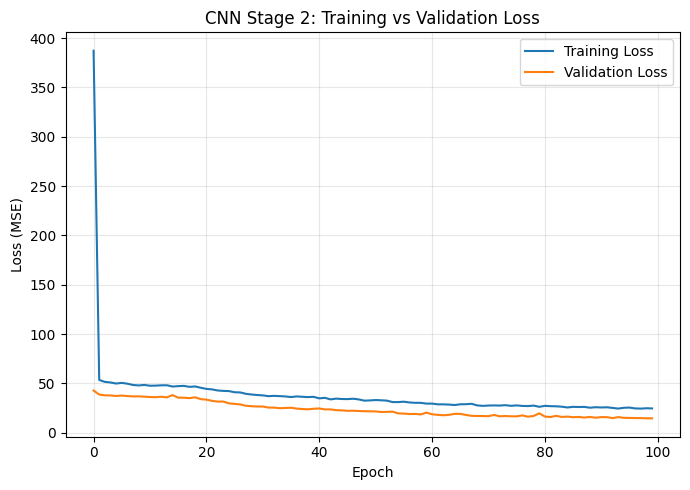

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history_cnn2.history['loss'], label='Training Loss')
plt.plot(history_cnn2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('CNN Stage 2: Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_stage2_loss_curve.png', dpi=300)
plt.show()

In [10]:
def prediction_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return 100 - mape

cnn_load_accuracy = prediction_accuracy(y1_test, pred_load_test)
cnn_latency_accuracy = prediction_accuracy(y2_test, pred_latency_test)

print(f"CNN Stage 1 (Load) Accuracy: {cnn_load_accuracy:.2f}%")
print(f"CNN Stage 2 (Latency) Accuracy: {cnn_latency_accuracy:.2f}%")

CNN Stage 1 (Load) Accuracy: 86.18%
CNN Stage 2 (Latency) Accuracy: 76.27%



MEC Server Selection



In [11]:
test_vehicles = test_df["Vehicle_ID"].unique()
all_servers = df["MEC_Server_ID"].unique()

rows = []
for vid in test_vehicles:
    vehicle_row = test_df[test_df["Vehicle_ID"] == vid].iloc[0]
    for server_id in all_servers:
        row = vehicle_row.copy()
        row["MEC_Server_ID"] = server_id
        rows.append(row)

candidates = pd.DataFrame(rows).reset_index(drop=True)

X1_cand = stage1_pre.transform(candidates[stage1_num + stage1_cat])
X1_cand_cnn = X1_cand.reshape(-1, n_features_1, 1)
candidates["Pred_Load"] = cnn_stage1.predict(X1_cand_cnn, verbose=0).flatten()

X2_cand = stage2_pre.transform(candidates[stage2_num + stage2_cat])
X2_cand_cnn = X2_cand.reshape(-1, n_features_2, 1)
candidates["Pred_Latency"] = cnn_stage2.predict(X2_cand_cnn, verbose=0).flatten()

cnn_best_choice = candidates.loc[candidates.groupby("Vehicle_ID")["Pred_Latency"].idxmin()]

print("CNN Shape of best_choice:", cnn_best_choice.shape)
print("\nCNN - How often each server gets picked as best:")
print(cnn_best_choice["MEC_Server_ID"].value_counts())

CNN Shape of best_choice: (40, 16)

CNN - How often each server gets picked as best:
MEC_Server_ID
5.0    19
6.0    14
3.0     6
2.0     1
Name: count, dtype: int64
